# Grid occupation
***
<small>Created: 14/04/2026   &emsp;   Updated : 14/04/2026<small>

La idea de este notebook es emplear el dataset contenido en ./Data/join/total_filt.nc y crear un grid de resolución modificable(aunque aquí usaremos resolución de un grado) que contenga información sobre el número de los perfil que está contenido en cada punto del grid y el número de perfiles en el mismo. La idea es seguir la línea de grid_2025, solo que no se calcularan temperaturas medias. El dataset resultante tendrá dimensiones de $(n_{lat}, n_{lon},n_{prof})$, donde son los índices de la latitud, longitud y el número de perfiles máximo que puede tener cada punto (que supondremos que es $100*resolución$) respectivamete. Como coordenadas se tendrá:

* $time \in \mathbb{R}^{n_{lat}\times n_{lon}\times n_{n_{{prof}}}} $
* $latitude \in \mathbb{R}^{n_{lat}}$
* $longitude \in \mathbb{R}^{n_{lon}}$

Además como variables tendremos:
* $profiles \in \mathbb{R}^{n_{lat}\times n_{lon}\times n_{n_{{prof}}}}$
* $n \in  \mathbb{R}^{n_{lat}\times n_{lon}}$
* $mask \in \mathbb{R}^{n_{lat}\times n_{lon}}$

In [1]:
# Import the necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import pandas as pd
import xarray as xr
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from Locate import locate

In [11]:
# Open the join dataset
path = './Data/join/total_filt.nc'
ds = xr.open_dataset(path)
ds

<xarray.Dataset> Size: 3GB
Dimensions:               (N_PROF: 21592, P: 6501)
Coordinates:
    time                  (N_PROF) datetime64[ns] 173kB ...
    section_id            (N_PROF) <U40 3MB ...
    file_name             (N_PROF) <U29 3MB ...
    latitude              (N_PROF) float64 173kB ...
    longitude             (N_PROF) float64 173kB ...
    pressure              (P) int64 52kB ...
Dimensions without coordinates: N_PROF, P
Data variables:
    ctd_temperature_filt  (N_PROF, P) float64 1GB ...
    ctd_salinity_filt     (N_PROF, P) float64 1GB ...
    ctd_oxygen_filt       (N_PROF, P) float64 1GB ...

In [12]:
# Defining the necessary variables
step = 1
resolution_str = str(step).split('.')[-1]
n_prof_max = int(step * 400)
longitude_space = np.arange(-180, 180 + step, step, dtype = float)
latitude_space = np.arange(-90, 90 + step, step, dtype = float)
ds_mask = xr.open_dataset('./Data/Mascara/mascara.nc')

In [13]:
# Function that returns the matrices of variables and coordinates
def grid_matrixs(ds, longitude, latitude, n_prof):
    # Create nan matrices
    profiles = np.full((len(latitude), len(longitude), n_prof), np.nan) # Contained profiles
    n = np.zeros((len(latitude), len(longitude))) # Number of profiles in each grid point
    time = np.full((len(latitude), len(longitude), n_prof), np.datetime64('NaT'), dtype='datetime64[ns]') # Date of every profile


    for prof in ds.N_PROF.values:
        if np.isnan(ds.latitude.values[prof]) == True or np.isnan(ds.longitude.values[prof]) == True: continue # If there is no latitude or longitude values skip

        ds.longitude.values[prof] = ds.longitude.values[prof] - 360 if ds.longitude.values[prof] > 180 else ds.longitude.values[prof] # Transform longitude from 0-360 to -180-180

        ilat = locate(ds.latitude.values[prof], latitude)
        ilon = locate(ds.longitude.values[prof], longitude)

        for k in range(n_prof):
            if np.isnan(profiles[ilat, ilon, k]) == True:
                profiles[ilat, ilon, k] = prof
                time[ilat, ilon, k] = ds.time[prof].values
                n[ilat, ilon] += 1
                break
    
    # Cut to made n_prof = n_max
    n[np.where(n == 0)] = np.nan
    n_max = int(np.nanmax(n))
    profiles = profiles[:, :, :n_max]
    time = time[:, :, :n_max]
    n_prof = n_max

    return (n, profiles, time, n_prof)

In [14]:
# Execute the function
n, profiles, time, n_prof = grid_matrixs(ds, longitude_space, latitude_space, n_prof = n_prof_max)

In [15]:
# Create the Dataset
profiles_ds = xr.Dataset(
    data_vars = dict(
        profiles = (["latitude", "longitude", "n_prof"], profiles)
    ),
    coords = dict(
        latitude = (["latitude"], latitude_space),
        longitude = (["longitude"], longitude_space),
        n_prof = (["n_prof"], np.arange(0, n_prof)),
        times = (["latitude", "longitude", "n_prof"], time),
        n = (["latitude", "longitude"], n)
    )
)



Una vez creado el dataset, le añadimos la variable mask

In [16]:
# Forcing mask to have the same coordinates as ds_profiles
ds_mask_align = ds_mask.reindex_like(profiles_ds, method = 'nearest')

# Creating the variable
profiles_ds['mask'] = ds_mask_align['mask']

# Set it as a coordinate
profiles_ds = profiles_ds.set_coords(['mask'])

In [17]:
# Saving in a netcdf file
profiles_ds.to_netcdf(f"./Data/grid/occupation_grid_{resolution_str}.nc")

In [18]:
profiles_ds

<xarray.Dataset> Size: 135MB
Dimensions:    (latitude: 181, longitude: 361, n_prof: 128)
Coordinates:
  * latitude   (latitude) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
    n          (latitude, longitude) float64 523kB nan nan nan ... nan nan nan
    mask       (latitude, longitude) float64 523kB ...
  * n_prof     (n_prof) int64 1kB 0 1 2 3 4 5 6 ... 121 122 123 124 125 126 127
    times      (latitude, longitude, n_prof) datetime64[ns] 67MB NaT NaT ... NaT
Data variables:
    profiles   (latitude, longitude, n_prof) float64 67MB nan nan ... nan nan

## Mapa de ocupaciones

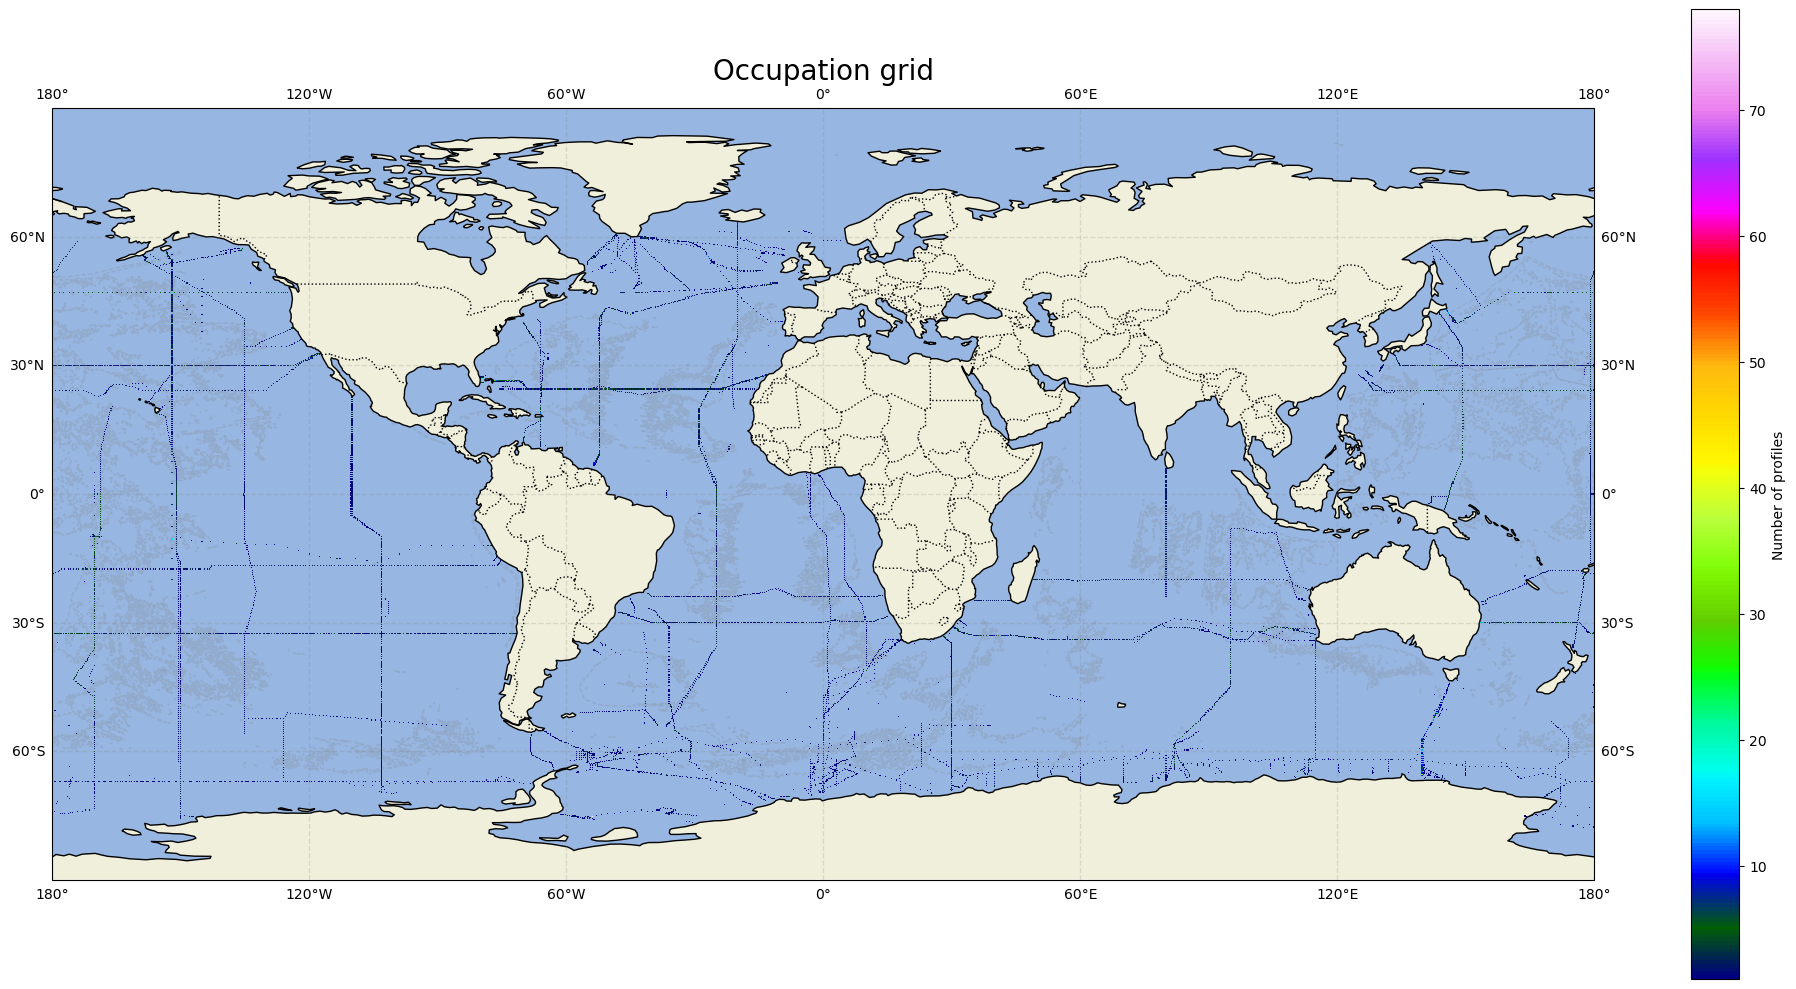

In [39]:
fig = plt.figure(figsize = (20, 10))
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=0))
ax.set_extent((-180, 180, -90, 90))
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle = ":")
bathym = cfeature.NaturalEarthFeature(name='bathymetry_F_5000', scale='10m', category='physical')
ax.add_feature(bathym, facecolor='none', edgecolor='gray', linestyle='dashed', linewidth=1, alpha = 0.2)
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')
profiles = profiles_ds.n.plot(ax = ax, transform = ccrs.PlateCarree(), add_colorbar = False, cmap = 'gist_ncar')
fig.colorbar(mappable = profiles, label = "Number of profiles")
ax.set_title("Occupation grid", fontsize = 20)
fig.tight_layout()
plt.savefig(f"./plots/Occupation_grids/occupation_grid_{resolution_str}.png")

### Cerrar todo

In [19]:
ds.close()
profiles_ds.close()
plt.close("all")